In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder, PowerTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold
# from sklearn.feature_selection import SelectKBest, chi2, f_classif, RFE, MutualInfoClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from itertools import combinations
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer

In [2]:
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('ggplot')
sns.set_palette("husl")

# Define Column Names for NSL-KDD (Standard List)
COL_NAMES = ["duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label", "difficulty_level"]

In [3]:
# Load Data (Assuming data is in ../SentinelNet/data or ../data relative to notebook)
# You might need to adjust the path based on your exact folder structure
train_path = './data/KDDTrain+.txt'
test_path = './data/KDDTest+.txt'

# Try loading with error handling for paths
try:
    df_train = pd.read_csv(train_path, header=None, names=COL_NAMES)
    df_test = pd.read_csv(test_path, header=None, names=COL_NAMES)
    print(f"Training Data Shape: {df_train.head()}")
    print(f"Test Data Shape: {df_test.tail()}")
except FileNotFoundError:
    print("Files not found. Please check the paths. Trying absolute paths or checking local directory...")
    # Fallback to local directory if paths are different
    if os.path.exists('KDDTrain+.txt'):
        df_train = pd.read_csv('KDDTrain+.txt', header=None, names=COL_NAMES)
        df_test = pd.read_csv('KDDTest+.txt', header=None, names=COL_NAMES)

# Combine for initial analysis (optional, but good for understanding full global distributions)
# We will split back later to avoid data leakage.
# For rigorous preprocessing, we fit on TRAIN and transform TEST.

Training Data Shape:    duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0

In [4]:
# Mapping Dictionary
attack_mapping = {
    'normal': 'normal',
    
    # DoS
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS', 'smurf': 'DoS', 'teardrop': 'DoS', 'mailbomb': 'DoS', 'apache2': 'DoS', 'processtable': 'DoS', 'udpstorm': 'DoS',
    
    # Probe
    'satan': 'Probe', 'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',
    
    # R2L
    'guess_passwd': 'R2L', 'ftp_write': 'R2L', 'imap': 'R2L', 'phf': 'R2L', 'multihop': 'R2L', 'warezmaster': 'R2L', 'warezclient': 'R2L', 'spy': 'R2L', 'xlock': 'R2L', 'xsnoop': 'R2L', 'snmpguess': 'R2L', 'snmpgetattack': 'R2L', 'httptunnel': 'R2L', 'sendmail': 'R2L', 'named': 'R2L',
    
    # U2R
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R', 'ps': 'U2R', 'xterm': 'U2R', 'sqlattack': 'U2R'
}

# Apply mapping
df_train['attack_class'] = df_train['label'].map(lambda x: attack_mapping.get(x, 'other'))
df_test['attack_class'] = df_test['label'].map(lambda x: attack_mapping.get(x, 'other'))

print("Training Class Distribution:")
print(df_train['attack_class'].value_counts())

Training Class Distribution:
attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [5]:
#Defining feature Groups

categorical_features = ['protocol_type','service','flag']
binary_features = ['land','logged_in','is_host_login','is_guest_login']
#All the other numerical values

numerical_features = [col for col in COL_NAMES if col not in categorical_features + binary_features +['label','difficulty_level']]

print(f"Categorical Features: {len(categorical_features)}")
print(f"Binary Features: {len(binary_features)}")
print(f"Numerical Features: {len(numerical_features)}")

print(df_train.isnull())

Categorical Features: 3
Binary Features: 4
Numerical Features: 34
        duration  protocol_type  service   flag  src_bytes  dst_bytes   land  \
0          False          False    False  False      False      False  False   
1          False          False    False  False      False      False  False   
2          False          False    False  False      False      False  False   
3          False          False    False  False      False      False  False   
4          False          False    False  False      False      False  False   
...          ...            ...      ...    ...        ...        ...    ...   
125968     False          False    False  False      False      False  False   
125969     False          False    False  False      False      False  False   
125970     False          False    False  False      False      False  False   
125971     False          False    False  False      False      False  False   
125972     False          False    False  False      F

In [6]:
def clean_outliers_isolation_forest(df,contamination = 0.01):
    iso_df  = df[numerical_features].copy()

    clf = IsolationForest(max_samples='auto',contamination = contamination, random_state = 42)

    outliers = clf.fit_predict(iso_df)

    n_outliers = (outliers == -1).sum()
    print(f"Identifies {n_outliers} Outlilers using the Isolation forest")

    return outliers
df_train['is_outlier'] = clean_outliers_isolation_forest(df_train)

Identifies 1256 Outlilers using the Isolation forest


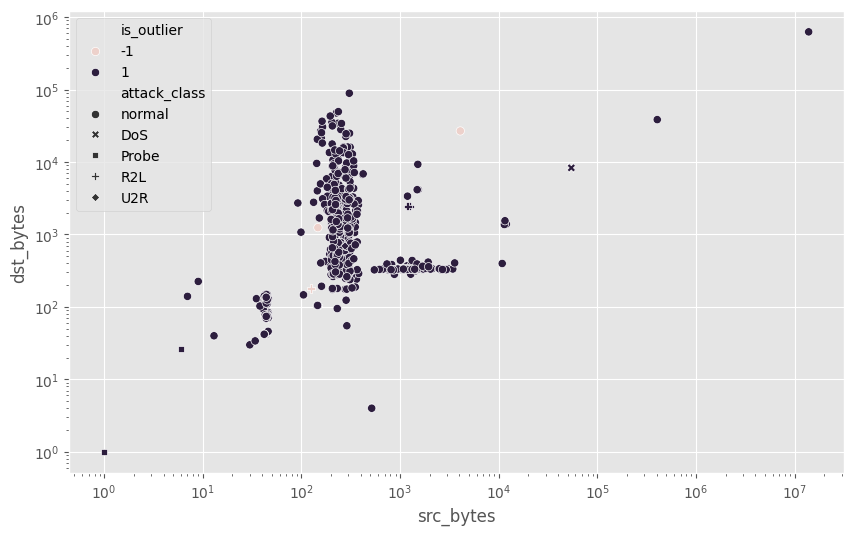

In [7]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_train[::100], x = 'src_bytes', y = 'dst_bytes', hue='is_outlier', style='attack_class')
plt.xscale('log')
plt.yscale('log')
plt.show()

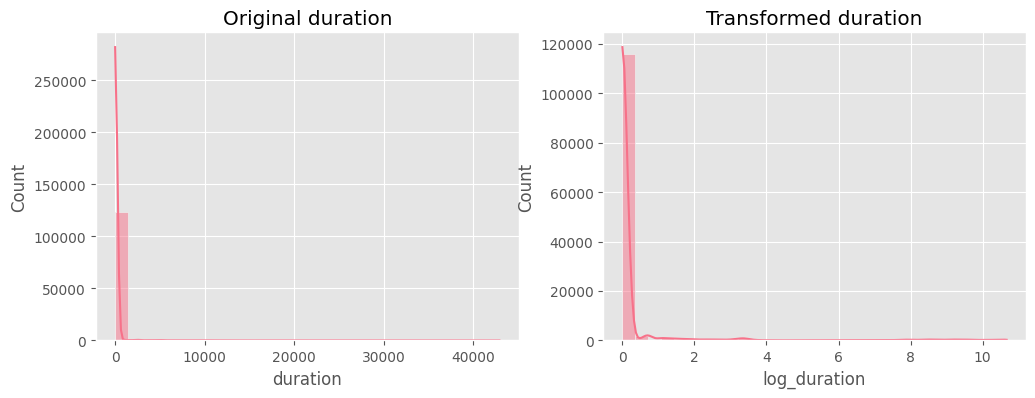

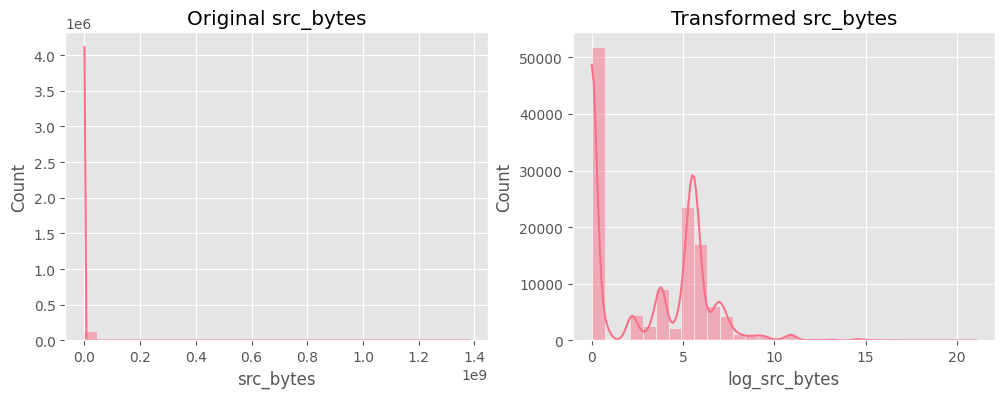

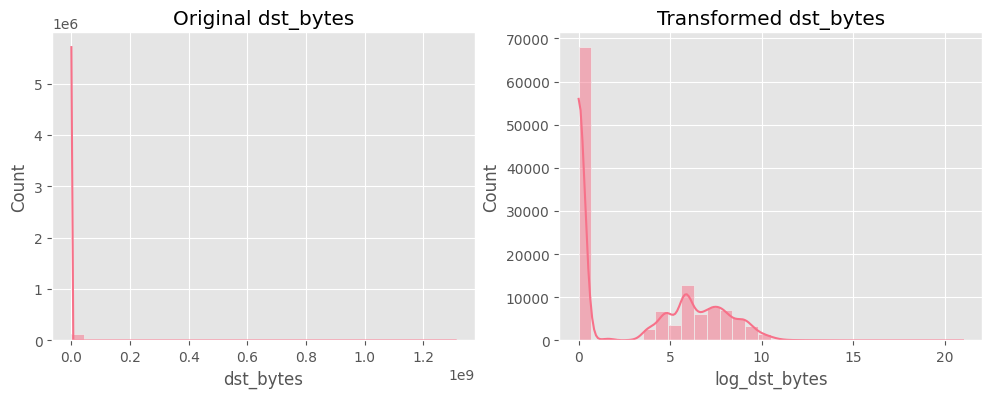

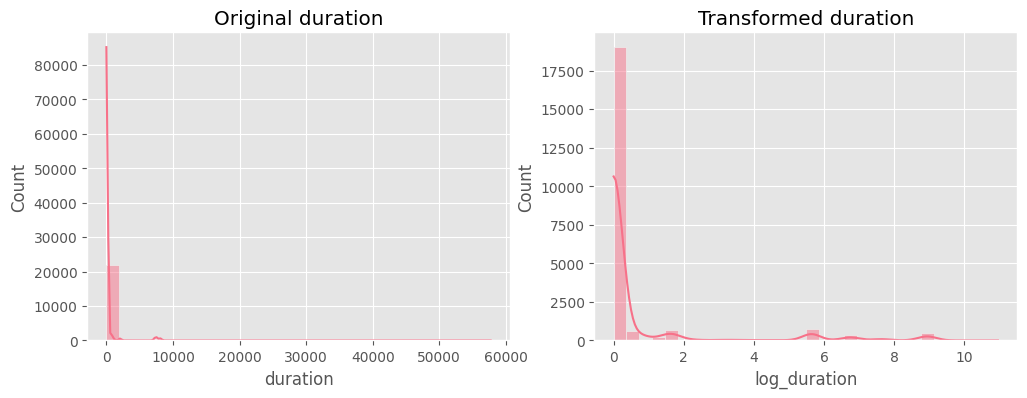

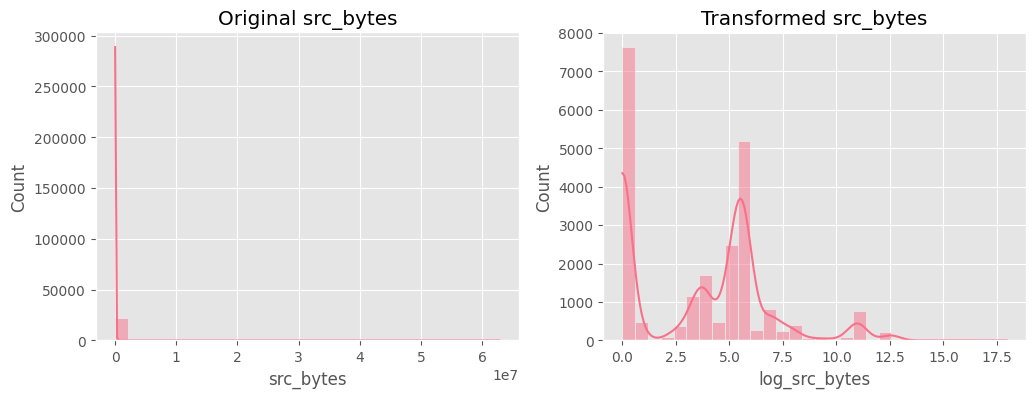

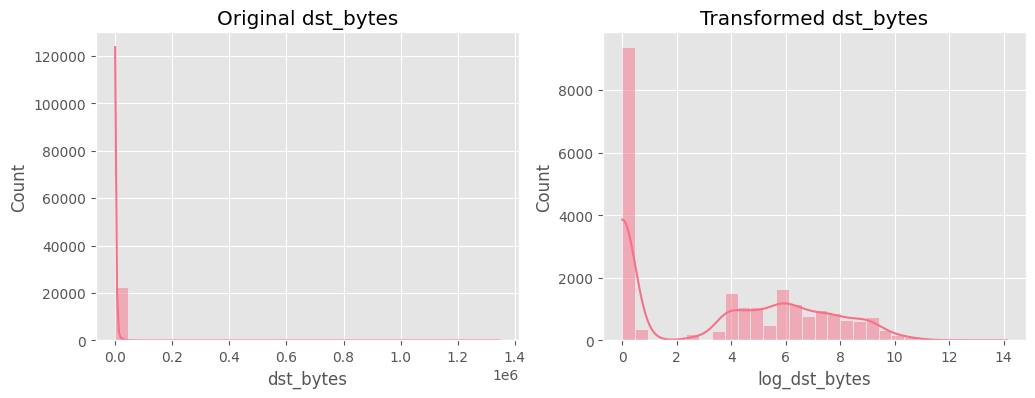

In [8]:
skewed_cols = ['duration','src_bytes','dst_bytes']

# Function for the Log1p transformation (log(x+1)) to handle the zeros

def apply_log_transform(df, cols):
    df_transform = df.copy()
    for col in cols:
        # creating a new column name
        new_col = f"log_{col}"
        # apply the logarithmic operation
        df_transform[new_col] = np.log1p(df_transform[col])

        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1)
        sns.histplot(df[col], bins=30, kde=True)
        plt.title(f"Original {col}")

        plt.subplot(1,2,2)
        sns.histplot(df_transform[new_col], bins=30, kde=True)
        plt.title(f"Transformed {col}")
        plt.show()
    # return the updated dataframe (fixed variable name)
    return df_transform

# apply the transformation to both train and test sets

df_train = apply_log_transform(df_train, skewed_cols)
df_test = apply_log_transform(df_test, skewed_cols)


In [9]:
import pandas as pd

# load the separate labeled dataset (file has no extension but is CSV formatted)
# adjust the path or filename if necessary
labeled_df = pd.read_csv("labeled_CSV", header=0)
labeled_df.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [10]:
import numpy as np

# work with the labeled dataset
log_df = labeled_df[['duration', 'src_bytes', 'dst_bytes']].copy()

for col in ['duration', 'src_bytes', 'dst_bytes']:
    log_df[col] = np.log1p(log_df[col])


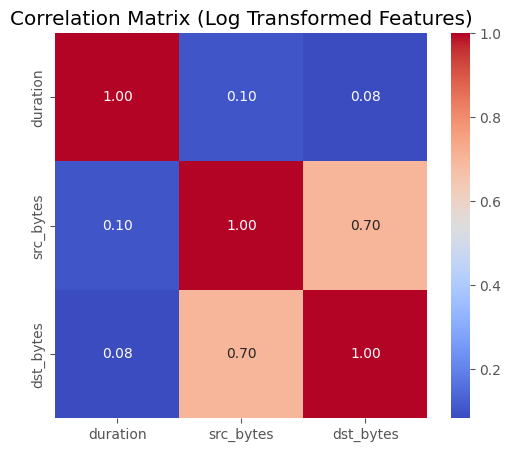

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

log_corr = log_df.corr()

plt.figure(figsize=(6,5))
sns.heatmap(log_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix (Log Transformed Features)")
plt.show()

In [12]:
def engineer_features(df):
    df_eng = df.copy()
    
    # 1. Total Bytes
    df_eng['total_bytes'] = df_eng['src_bytes'] + df_eng['dst_bytes']
    
    # 2. Byte Ratio (Handle division by zero)
    df_eng['src_bytes_ratio'] = df_eng['src_bytes'] / (df_eng['total_bytes'] + 1e-5)
    
    # 3. Load / Packet Rate
    # If duration is 0, we assume it's a single instantaneous event (rate = count)
    df_eng['packet_rate'] = df_eng['count'] / (df_eng['duration'] + 1e-5)
    
    # 4. Title: Flow Asymmetry
    df_eng['byte_diff'] = abs(df_eng['src_bytes'] - df_eng['dst_bytes'])
    
    # 5. Flag interactions (example: is it an error flag?)
    error_flags = ['S0', 'S1', 'S2', 'S3', 'REJ']
    df_eng['is_error_flag'] = df_eng['flag'].isin(error_flags).astype(int)
    
    # 6. Critical Host Interaction
    # Interaction between 'same_srv_rate' and 'dst_host_same_srv_rate'
    df_eng['same_srv_interaction'] = df_eng['same_srv_rate'] * df_eng['dst_host_same_srv_rate']
    
    return df_eng

df_train = engineer_features(df_train)
df_test = engineer_features(df_test)

print("New Feature Set Head:")
print(df_train[['src_bytes_ratio', 'packet_rate', 'is_error_flag', 'same_srv_interaction']].head())

New Feature Set Head:
   src_bytes_ratio  packet_rate  is_error_flag  same_srv_interaction
0         1.000000     200000.0              0                 0.170
1         1.000000    1300000.0              0                 0.000
2         0.000000   12300000.0              1                 0.005
3         0.027668     500000.0              0                 1.000
4         0.321486    3000000.0              0                 1.000


In [13]:
# second version of engineer_features (also superseded by final helper defined later)
# def engineer_features(df):
#     df_eng = df.copy()
#
#     #  Total Bytes
#     df_eng['total_bytes'] = df_eng['src_bytes'] + df_eng['dst_bytes']
#
#     #  Byte Ratio (avoid division by zero)
#     df_eng['src_bytes_ratio'] = df_eng['src_bytes'] / (df_eng['total_bytes'] + 1)
#
#     #  Packet Rate (handle duration = 0)
#     df_eng['packet_rate'] = df_eng['count'] / (df_eng['duration'] + 1)
#
#     # Logged Duration (optional extra feature)
#     df_eng['log_duration'] = np.log1p(df_eng['duration'])
#
#     return df_eng


In [14]:
# use the most recent version of the feature‑engineering helper on the labeled dataset

df_transformed = engineer_features(labeled_df)

df_transformed.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty_level,total_bytes,src_bytes_ratio,packet_rate,byte_diff,is_error_flag,same_srv_interaction
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.05,0.00,normal,20,491,1.000000,200000.0,491,0,0.170
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.00,normal,15,146,1.000000,1300000.0,146,0,0.000
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.00,0.00,neptune,19,0,0.000000,12300000.0,0,1,0.005
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.01,normal,21,8385,0.027668,500000.0,7921,0,1.000
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,normal,21,619,0.321486,3000000.0,221,0,1.000


In [15]:
# review the column names of the labeled dataset
labeled_df.columns


Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class', 'difficulty_level'],
      dtype='object')

In [16]:
df_train['service']


0         ftp_data
1            other
2          private
3             http
4             http
            ...   
125968     private
125969     private
125970        smtp
125971      klogin
125972    ftp_data
Name: service, Length: 125973, dtype: object

In [17]:
import numpy as np

def engineer_features(df):
    df_eng = df.copy()

    # 1️⃣ Total Bytes
    df_eng['total_bytes'] = df_eng['src_bytes'] + df_eng['dst_bytes']

    # 2️⃣ Source Byte Ratio (safe division)
    df_eng['src_bytes_ratio'] = df_eng['src_bytes'] / (df_eng['total_bytes'] + 1)

    # 3️⃣ Packet Rate (handle division by zero safely)
    df_eng['packet_rate'] = df_eng['count'] / (df_eng['duration'] + 1)

    # 4️⃣ Log Duration
    df_eng['log_duration'] = np.log1p(df_eng['duration'])

    return df_eng

In [18]:
# run the final version of the feature engineering function on the labeled dataset

df_transformed = engineer_features(labeled_df)

df_transformed.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty_level,total_bytes,src_bytes_ratio,packet_rate,log_duration
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.00,0.00,0.05,0.00,normal,20,491,0.997967,2.0,0.0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.00,0.00,0.00,normal,15,146,0.993197,13.0,0.0
2,0,tcp,private,S0,0,0,0,0,0,0,...,1.00,1.00,0.00,0.00,neptune,19,0,0.000000,123.0,0.0
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.03,0.01,0.00,0.01,normal,21,8385,0.027665,5.0,0.0
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,normal,21,619,0.320968,30.0,0.0


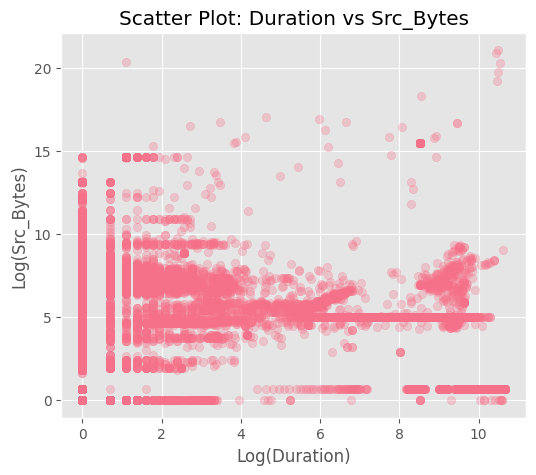

Correlation: 0.10388711355187441


In [19]:
plt.figure(figsize=(6,5))
plt.scatter(log_df['duration'], log_df['src_bytes'], alpha=0.3)
plt.xlabel('Log(Duration)')
plt.ylabel('Log(Src_Bytes)')
plt.title('Scatter Plot: Duration vs Src_Bytes')
plt.show()

print("Correlation:", log_df['duration'].corr(log_df['src_bytes']))

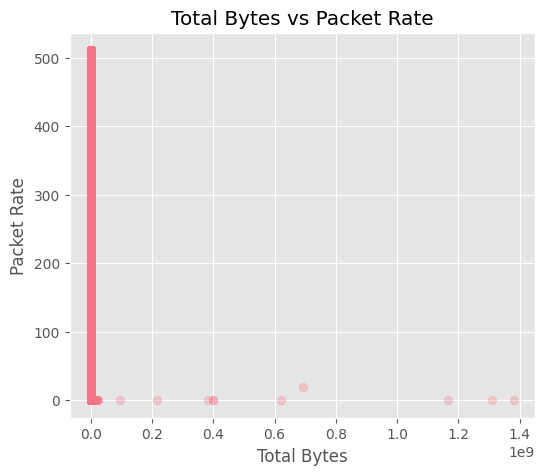

In [20]:
plt.figure(figsize=(6,5))
plt.scatter(df_transformed['total_bytes'],
            df_transformed['packet_rate'],
            alpha=0.3)

plt.xlabel("Total Bytes")
plt.ylabel("Packet Rate")
plt.title("Total Bytes vs Packet Rate")
plt.show()

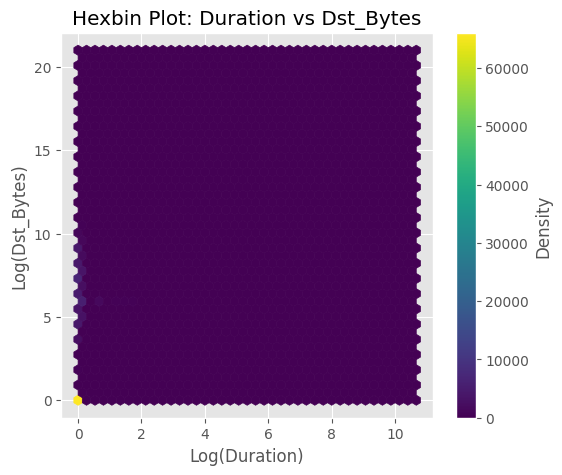

Correlation: 0.08349041551811516


In [21]:
plt.figure(figsize=(6,5))
plt.hexbin(log_df['duration'], log_df['dst_bytes'], gridsize=40)
plt.xlabel('Log(Duration)')
plt.ylabel('Log(Dst_Bytes)')
plt.title('Hexbin Plot: Duration vs Dst_Bytes')
plt.colorbar(label='Density')
plt.show()

print("Correlation:", log_df['duration'].corr(log_df['dst_bytes']))

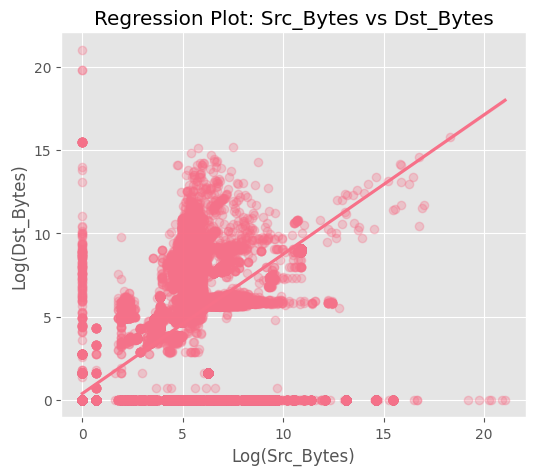

Correlation: 0.7023503920159611


In [22]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.regplot(x=log_df['src_bytes'], y=log_df['dst_bytes'], scatter_kws={'alpha':0.3})
plt.xlabel('Log(Src_Bytes)')
plt.ylabel('Log(Dst_Bytes)')
plt.title('Regression Plot: Src_Bytes vs Dst_Bytes')
plt.show()

print("Correlation:", log_df['src_bytes'].corr(log_df['dst_bytes']))

In [23]:
ohe = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
cols_to_encode = ['protocol_type','flag']

#Fit and Train

ohe_train = pd.DataFrame(ohe.fit_transform(df_train[cols_to_encode]))
ohe_train.columns = ohe.get_feature_names_out(cols_to_encode)
ohe_train.index = df_train.index
# ohe_train.index

#Transform Test

ohe_test = pd.DataFrame(ohe.transform(df_test[cols_to_encode]))
ohe_test.columns = ohe.get_feature_names_out(cols_to_encode)
ohe_test.index = df_test.index

service_freq = df_train['service'].value_counts(normalize = True)
df_train['service_freq'] = df_train['service'].map(service_freq)
df_test['service_freq'] = df_test['service'].map(service_freq).fillna(0)

df_train_encode = pd.concat([df_train,ohe_train],axis = 1)
df_test_encode = pd.concat([df_test,ohe_test],axis = 1)

df_train_encode.columns
# df_train_encode

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label', 'difficulty_level', 'attack_class',
       'is_outlier', 'log_duration', 'log_src_bytes', 'log_dst_bytes',
       'total_bytes', 'src_bytes_ratio', 'packet_rate', 'byte_dif

In [24]:
print(df_train_encode.columns)

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label', 'difficulty_level', 'attack_class',
       'is_outlier', 'log_duration', 'log_src_bytes', 'log_dst_bytes',
       'total_bytes', 'src_bytes_ratio', 'packet_rate', 'byte_dif

In [25]:
df_test_encode

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,tcp,private,REJ,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,tcp,private,REJ,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,0,tcp,smtp,SF,794,333,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22540,0,tcp,http,SF,317,938,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22541,0,tcp,http,SF,54540,8314,0,0,0,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22542,0,udp,domain_u,SF,42,42,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [26]:
df_train_encode.drop(columns=['protocol_type','flag','service'],inplace = True)
df_test_encode.drop(columns=['protocol_type','flag','service'],inplace = True)

In [27]:
print(df_train_encode.shape)

df_test_encode

(125973, 66)


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,0,0,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,12983,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,20,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1,0,15,0,0,0,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,0,794,333,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22540,0,317,938,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22541,0,54540,8314,0,0,0,2,0,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22542,0,42,42,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [28]:
df_train_encode

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,491,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0,146,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0,232,8153,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0,199,420,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
125969,8,105,145,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
125970,0,2231,384,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
125971,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [29]:
#Co-relation Filter

corr_matrix = df_train_encode.select_dtypes(include=[np.number]).corr().abs()
#Upper Triangle of teh co-realtion matrix

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))

#find features with corelation greater then 0.95
to_drop = [column for column in upper.columns if any (upper[column]>0.95)]
print(f"Features to drop due to high corelation (>0.95): {to_drop}")

#Drop them

df_train_reduce = df_train_encode.drop(columns=to_drop)
df_test_reduce = df_test_encode.drop(columns= to_drop)
try:
    cols_dropped_from_test = [c for c in top_drop if c in df_test_encode.columns]
    df_test_reduce = df_test_encode.drop(columns= cols_dropped_from_test)
except:
    pass
print(f"Reduce Shape: {df_train_reduce.shape}")

Features to drop due to high corelation (>0.95): ['num_root', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_srv_rerror_rate', 'packet_rate', 'byte_diff', 'same_srv_interaction', 'flag_S0']
Reduce Shape: (125973, 56)


In [30]:
d= df_train_encode[to_drop]
d.iloc[:10]

,num_root,srv_serror_rate,srv_rerror_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_srv_rerror_rate,packet_rate,byte_diff,same_srv_interaction,flag_S0
0,0,0.0,0.0,0.00,0.00,0.00,200000.0,491,0.1700,0.0
1,0,0.0,0.0,0.00,0.00,0.00,1300000.0,146,0.0000,0.0
2,0,1.0,0.0,1.00,1.00,0.00,12300000.0,0,0.0050,1.0
3,0,0.2,0.0,0.03,0.01,0.01,500000.0,7921,1.0000,0.0
4,0,0.0,0.0,0.00,0.00,0.00,3000000.0,221,1.0000,0.0
5,0,0.0,1.0,0.00,0.00,1.00,12100000.0,0,0.0112,0.0
6,0,1.0,0.0,1.00,1.00,0.00,16600000.0,0,0.0020,1.0
7,0,1.0,0.0,1.00,1.00,0.00,11700000.0,0,0.0084,1.0
8,0,1.0,0.0,1.00,1.00,0.00,27000000.0,0,0.0081,1.0
9,0,1.0,0.0,1.00,1.00,0.00,13300000.0,0,0.0030,1.0


In [31]:
# Select label columns correctly
label_cols = ['label', 'attack_class', 'difficulty_levels']
label = df_train_encode[[c for c in label_cols if c in df_train_encode.columns]]

# Correlation Filter
corr_matrix = df_train_encode.select_dtypes(include=[np.number]).corr().abs()

# Upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.95
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
print(f"Features to drop due to high correlation (>0.95): {to_drop}")

# Drop highly correlated features from train and test sets
df_train_reduce = df_train_encode.drop(columns=to_drop)

# Correct completed last line
df_test_reduce = df_test_encode.drop(columns=to_drop, errors='ignore')

print(f"Reduced Train Shape: {df_train_reduce.shape}")
print(f"Reduced Test Shape: {df_test_reduce.shape}")

Features to drop due to high correlation (>0.95): ['num_root', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_srv_rerror_rate', 'packet_rate', 'byte_diff', 'same_srv_interaction', 'flag_S0']
Reduced Train Shape: (125973, 56)
Reduced Test Shape: (22544, 55)


In [32]:
# ==============================
# Encode categorical features
# ==============================

# Copy datasets
df_train_encode = df_train.copy()
df_test_encode = df_test.copy()

# Find categorical columns
cat_cols = df_train_encode.select_dtypes(include=['object']).columns

# Apply Label Encoding
le_dict = {}

for col in cat_cols:
    le = LabelEncoder()

    # Fit on combined data to avoid unseen labels in test
    combined = pd.concat([df_train_encode[col], df_test_encode[col]], axis=0)

    le.fit(combined)

    df_train_encode[col] = le.transform(df_train_encode[col])
    df_test_encode[col] = le.transform(df_test_encode[col])

    le_dict[col] = le

print("Encoding completed ")

Encoding completed 


In [33]:
# Select label columns correctly
label_cols = ['label', 'attack_class', 'difficulty_level']

label = df_train_encode[
    [c for c in label_cols if c in df_train_encode.columns]
]

# Correlation Filter
corr_matrix = df_train_encode.select_dtypes(include=[np.number]).corr().abs()

# Upper triangle
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Features with correlation > 0.95
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"Features to drop due to high correlation (>0.95): {to_drop}")

# Drop features
df_train_reduce = df_train_encode.drop(columns=to_drop)
df_test_reduce = df_test_encode.drop(columns=to_drop, errors='ignore')

print(f"Reduced Train Shape: {df_train_reduce.shape}")
print(f"Reduced Test Shape: {df_test_reduce.shape}")

Features to drop due to high correlation (>0.95): ['num_root', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_srv_rerror_rate', 'packet_rate', 'byte_diff', 'same_srv_interaction']
Reduced Train Shape: (125973, 46)
Reduced Test Shape: (22544, 45)


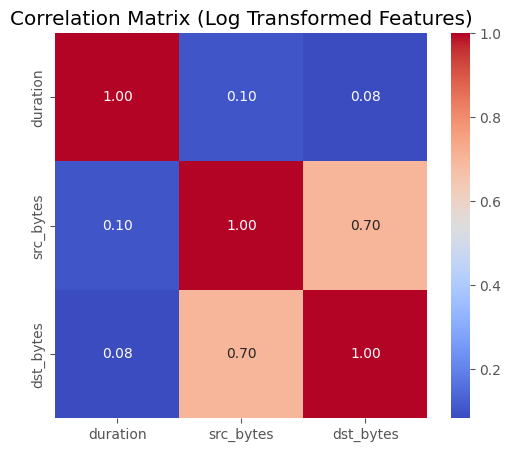

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(log_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix (Log Transformed Features)")
plt.show()

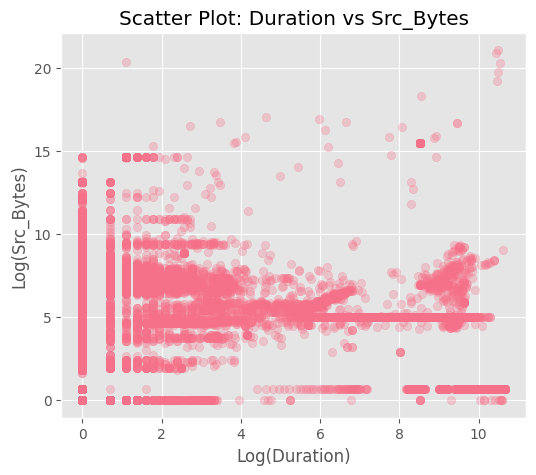

Correlation: 0.10388711355187441


In [35]:
plt.figure(figsize=(6,5))
plt.scatter(log_df['duration'], log_df['src_bytes'], alpha=0.3)
plt.xlabel('Log(Duration)')
plt.ylabel('Log(Src_Bytes)')
plt.title('Scatter Plot: Duration vs Src_Bytes')
plt.show()

print("Correlation:", log_df['duration'].corr(log_df['src_bytes']))

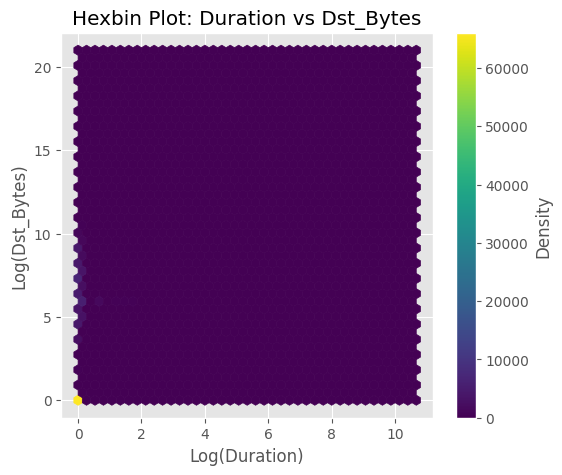

Correlation: 0.08349041551811516


In [36]:
plt.figure(figsize=(6,5))
plt.hexbin(log_df['duration'], log_df['dst_bytes'], gridsize=40)
plt.xlabel('Log(Duration)')
plt.ylabel('Log(Dst_Bytes)')
plt.title('Hexbin Plot: Duration vs Dst_Bytes')
plt.colorbar(label='Density')
plt.show()

print("Correlation:", log_df['duration'].corr(log_df['dst_bytes']))

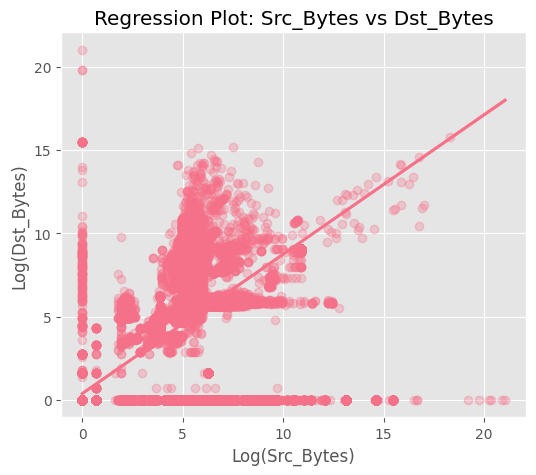

Correlation: 0.7023503920159611


In [37]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.regplot(x=log_df['src_bytes'], y=log_df['dst_bytes'], scatter_kws={'alpha':0.3})
plt.xlabel('Log(Src_Bytes)')
plt.ylabel('Log(Dst_Bytes)')
plt.title('Regression Plot: Src_Bytes vs Dst_Bytes')
plt.show()

print("Correlation:", log_df['src_bytes'].corr(log_df['dst_bytes']))


In [38]:
import numpy as np
import pandas as pd
#Load dataset
train_df = pd.read_csv("labeled_CSV")


In [39]:
# Select only numeric columns
numeric_cols = train_df.select_dtypes(include=np.number).columns

# Create copy
log_train_df = train_df.copy()

# Apply log(1 + x) transformation
for col in numeric_cols:
    log_train_df[col] = np.log1p(log_train_df[col])
    log_train_df.to_csv("log_transformed_train.csv", index=False)
print("Log-transformed dataset saved successfully.")

Log-transformed dataset saved successfully.


In [40]:
# Create copy
log_train_df = train_df.copy()

# Apply log(1 + x) transformation
for col in numeric_cols:
    log_train_df[col] = np.log1p(log_train_df[col])

In [41]:
log_train_df.to_csv("log_transformed_train.csv", index=False)

print("Log-transformed dataset saved successfully.")

Log-transformed dataset saved successfully.
